1.9125


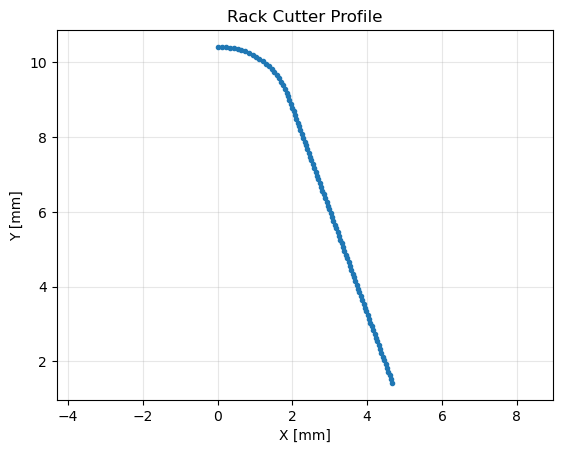

In [1]:
from gears.main.core import rackCutter
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
import screwCalculus as sc
from palloid_bevel_gears import *

# m = 4.25; alpha = 20*np.pi/180; rc = 0.45*m; p_shift = -1.2; 

pressure_angle = 20 * np.pi/180
module = 4.25
rc = 0.45*module
print(rc)
p_shift = -1.2
rack = rackCutter().create_standard(parametric=True)

params = [module, pressure_angle, rc, p_shift, 0]
u_vec = np.linspace(0, 2.5*module, 100).reshape(1, -1)
p = rack.p_fun(params, u_vec).full()
x = p[0,:]
y = p[1,:]
plt.plot(x, y, marker = '.')
plt.axis("equal")
plt.title('Rack Cutter Profile')
plt.xlabel('X [mm]')
plt.ylabel('Y [mm]') 
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
import ipywidgets as widgets
from IPython.display import display
import easy_plot as ep
slider = widgets.FloatSlider(value=1.0, min=0, max=10, step=0.1, description = 'm')
display(slider)

x = np.linspace(0,10, 10)
y = x

X, Y = np.meshgrid(x, y, indexing = 'ij')
Z = np.random.rand(X.shape[0], X.shape[1])

F = ep.Figure()

s = ep.surface(F, X, Y, Z, style = 'wireframe', show_edges=True)

F.show()

def update(change):
    Z = np.random.rand(X.shape[0], X.shape[1])
    s.updateData(np.hstack((X.reshape(-1,1), Y.reshape(-1, 1), Z.reshape(-1, 1))))

slider.observe(update, names='value')

FloatSlider(value=1.0, description='m', max=10.0)

In [ ]:
# sample some points
p_cnv, n_cnv = crown_wheel_surf()
p_cvx, n_cvx = crown_wheel_surf(flank = 'convex')

m = 4.5; alpha_cnv = 25*np.pi/180; alpha_cvx = 25*np.pi/180; rc_cnv = 0.3*m; rc_cvx= 0.3*m; prof_shift = 0; bl = 0; rb = 70.0 

theta_init = np.sqrt((rb*1.1/rb)**2 - 1)
theta_end = np.sqrt((rb*1.5/rb)**2 - 1)
params_num = [m, alpha_cnv, alpha_cvx, rc_cnv, rc_cvx, prof_shift, bl, rb]

ybar = 1.25*m + rc * (np.sin(alpha_cnv) - 1)
u2 = (ca.pi/2-alpha_cnv)*rc + ca.pi*m/4 + bl - rc*ca.cos(alpha_cnv) - ybar*ca.tan(alpha_cnv)
u3 = (ybar + 1.0*m)/np.cos(alpha_cnv) + u2

u_vec = np.linspace(0, u3, 100)
theta_vec = np.linspace(theta_init, theta_end, 100)

U, T = np.meshgrid(u_vec, theta_vec, indexing='ij')

shp = U.shape

UT = np.vstack((U.reshape(1, -1), T.reshape(1, -1)))

p_num = p_cnv(params_num, UT).full()
p_num_cvx = p_cvx(params_num, UT).full()

X = p_num[0,:].reshape(shp[0], shp[1], order = 'C')
Y = p_num[1,:].reshape(shp[0], shp[1], order = 'C')
Z = p_num[2,:].reshape(shp[0], shp[1], order = 'C')

X_cvx = p_num_cvx[0,:].reshape(shp[0], shp[1], order = 'C')
Y_cvx = p_num_cvx[1,:].reshape(shp[0], shp[1], order = 'C')
Z_cvx = p_num_cvx[2,:].reshape(shp[0], shp[1], order = 'C')
import easy_plot as ep

F = ep.Figure()
s = ep.surface(F, X, Y, Z)
s_cvx = ep.surface(F, X_cvx, Y_cvx, Z_cvx)
F.show()



In [2]:
# numerical parameters
m = 4.25; alpha_cnv = 20*np.pi/180; alpha_cvx = 20*np.pi/180; rc_cnv = 0.25*m;rc_cvx = 0.25*m; p_shift = 0; backlash = 0.3
rb = 82
ratio_roll = 1.0
delta_g = 72*np.pi/180
blank_tilt = 0
z_offset = 4.5
x_offset = 0
y_offset = 0


outer_cone_dist =  123.9463
inner_cone_dist =  82.5


#        m, alpha, rc, rb
params = [m, alpha_cnv, alpha_cvx,rc_cnv,rc_cvx, p_shift, backlash, rb]
kinematic_params = [ratio_roll, delta_g, z_offset]


params = [ 4.25000000e+00,  3.78540874e-01,  3.92506127e-01,  7.81296260e-01,
  1.33089022e+00, -0.0,  2.16505390e-01,  8.23584834e+01]
kinematic_params = [1.01297484e+00,  1.25865390e+00, -1.28453060e-02, -1.00000001e+00,
  1.27626173e+00,  4.73778896e+00]

ybar = 1.25*m + rc * (np.sin(alpha_cnv) - 1)
u2 = (ca.pi/2-alpha_cnv)*rc + ca.pi*m/4 - rc*ca.cos(alpha_cnv) - ybar*ca.tan(alpha_cnv)
u3 = (ybar + 1.0*m)/np.cos(alpha_cnv) + u2

print(u3)

theta_init = np.sqrt((inner_cone_dist/rb)**2 - 1)
theta_end = np.sqrt((outer_cone_dist/rb)**2 - 1)
# theta_init = np.sqrt((65/rb)**2 - 1)
# theta_end = np.sqrt((105.4/rb)**2 - 1)
u_num = np.linspace(0, u3, 150)
theta_num = np.linspace(theta_init, theta_end, 50)


u_sym = ca.SX.sym('u')
theta_sym = ca.SX.sym('theta')
psi_sym = ca.SX.sym('psi')

eq_cnv, pg_cnv, ng_cnv = eq_meshing()
eq_cvx, pg_cvx, ng_cvx = eq_meshing(flank = 'convex')

U, T = np.meshgrid(u_num, theta_num, indexing='ij')

shp = U.shape


eq_cnv = eq_cnv(params, kinematic_params, ca.vertcat(u_sym, theta_sym, psi_sym))
eq_cvx = eq_cvx(params, kinematic_params, ca.vertcat(u_sym, theta_sym, psi_sym))

problem_cnv = {'x': psi_sym, 'p': ca.vertcat(u_sym, theta_sym), 'g': eq_cnv}
problem_cvx = {'x': psi_sym, 'p': ca.vertcat(u_sym, theta_sym), 'g': eq_cvx}
solver_cnv = ca.rootfinder('solver', 'newton', problem_cnv, {'error_on_fail': False})
solver_cvx = ca.rootfinder('solver', 'newton', problem_cvx, {'error_on_fail': False})

P_cnv = U*0
P_cvx = U*0
for ii in range(0, shp[0]):
    for jj in range(0, shp[1]):
        sol = solver_cnv(x0 = 0, p = ca.vertcat(U[ii,jj], T[ii, jj]))
        P_cnv[ii, jj] = sol['x'].full()
        sol = solver_cvx(x0 = 0, p = ca.vertcat(U[ii,jj], T[ii, jj]))
        P_cvx[ii, jj] = sol['x'].full()

u_mid = u3/2
theta_mid = (theta_end+theta_init)/2

sol = solver_cvx(x0 = 0, p = ca.vertcat(u_mid, theta_mid))
psi_rephase = sol['x'].full()

print(theta_mid)



11.238815976656134


C:\Users\egrab\AppData\Local\Temp\ipykernel_42536\1005793647.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  P_cnv[ii, jj] = sol['x'].full()
C:\Users\egrab\AppData\Local\Temp\ipykernel_42536\1005793647.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  P_cvx[ii, jj] = sol['x'].full()


0.6220347961328855


In [3]:
path = r'C:\Users\egrab\Desktop\Ferrari\GT_2025_reverse_N2\Scansioni'

file_cnv = 'ConcaveCorona.dat'
file_cvx = 'ConvexCorona.dat'

data =  np.loadtxt(path+'\\'+file_cnv)
raw_points_cvx = data[:, 0:3]

data =  np.loadtxt(path+'\\'+file_cvx)
raw_points_cnv = data[:, 0:3]

In [4]:

# load target points processed in matlab (it has better plotting for selecting points)
from scipy.io import loadmat
target_points_cvx = loadmat('Gear_cnv.mat')['target_point_cnv']
target_points_cnv = loadmat('Gear_cvx.mat')['target_point_cvx']
print(np.isnan(target_points_cnv).sum())

p_num = pg_cnv(params, kinematic_params, ca.vertcat(U.reshape(1, -1), T.reshape(1,-1), P_cnv.reshape(1, -1)) ).full()
n_num = ng_cnv(params, kinematic_params, ca.vertcat(U.reshape(1, -1), T.reshape(1,-1), P_cnv.reshape(1, -1)) ).full()

X_cvx = p_num[0, :].reshape(shp)
Y_cvx = p_num[1, :].reshape(shp)
Z_cvx = p_num[2, :].reshape(shp)

p_num = pg_cvx(params, kinematic_params, ca.vertcat(U.reshape(1, -1), T.reshape(1,-1), P_cvx.reshape(1, -1)) ).full()
p_rephase = pg_cvx(params, kinematic_params, ca.vertcat(u_mid, theta_mid, psi_rephase) ).full().flatten()

solver_sampling, _, _ = rz_sampling(flank = 'convex')
z = target_points_cnv[156,2]; R = np.sqrt(target_points_cnv[156,0]**2 + target_points_cnv[156, 1]**2); x_target = target_points_cnv[156, 0]; y_target = target_points_cnv[156, 1]
sol = solver_sampling(x0 = ca.vertcat(u_mid, theta_mid, 0), p = ca.vertcat(params, kinematic_params, z, R))['x']
p_rephase = pg_cvx(params, kinematic_params, ca.vertcat(sol[0], sol[1], sol[2]) ).full().flatten()

X_cnv = p_num[0, :].reshape(shp)
Y_cnv = p_num[1, :].reshape(shp)
Z_cnv = p_num[2, :].reshape(shp)

L = U.reshape(1, -1).shape[1]
id_rephase = int(np.floor(L/2))
y_coord = Y_cnv.flatten()
x_coord = X_cnv.flatten()

# print(x_coord[id_rephase], y_coord[id_rephase])
L = target_points_cnv.shape[0]

id_target = int(np.floor(L/2))
reph_angle = +np.arctan2(p_rephase[1], p_rephase[0]) - np.arctan2(y_target, x_target  )

# print(np.arctan2(p_rephase[1], p_rephase[0]))
target_points_cnv = (sc.rotZ(reph_angle) @ target_points_cnv.T).T
target_points_cvx = (sc.rotZ(reph_angle) @ target_points_cvx.T).T

F = ep.Figure()
s = ep.surface(F, X_cnv, Y_cnv, Z_cnv, opacity=1)
s_cvx = ep.surface(F, X_cvx, Y_cvx, Z_cvx, opacity=1)
# scatter_target = ep.scatter(F, target_points_cnv[:,0], target_points_cnv[:,1], z = target_points_cnv[:,2])
# scatter_target_cvx = ep.scatter(F, target_points_cvx[:,0], target_points_cvx[:,1], z = target_points_cvx[:,2])
# scatter_point = ep.scatter(F, [p_rephase[0]], [p_rephase[1]], z = [p_rephase[2]])

raw_points_cvx_rot = (sc.rotZ(reph_angle) @ raw_points_cvx.T).T
raw_points_cnv_rot = (sc.rotZ(reph_angle) @ raw_points_cnv.T).T
scatter_raw_cvx = ep.scatter(F, raw_points_cvx_rot[:, 0], raw_points_cvx_rot[:, 1], z = raw_points_cvx_rot[:, 2])
scatter_raw_cnv = ep.scatter(F, raw_points_cnv_rot[:, 0], raw_points_cnv_rot[:, 1], z = raw_points_cnv_rot[:, 2])
F.show()



0


In [5]:
eq_residuals = residuals_sampling_eqs(flank='concave')

p_num = pg_cnv(params, kinematic_params, ca.vertcat(U.reshape(1, -1), T.reshape(1,-1), P_cnv.reshape(1, -1)) ).full()
n_num = ng_cnv(params, kinematic_params, ca.vertcat(U.reshape(1, -1), T.reshape(1,-1), P_cnv.reshape(1, -1)) ).full()
p_target = target_points_cvx.T


u_sym = ca.SX.sym('u')
theta_sym = ca.SX.sym('theta')
psi_sym = ca.SX.sym('psi')
h_sym = ca.SX.sym('h')
p_star = ca.SX.sym('ps', 3, 1)

eq_expr = eq_residuals(params, kinematic_params, p_star, ca.vertcat(u_sym, theta_sym, psi_sym, h_sym))

problem = {'x': ca.vertcat(u_sym, theta_sym, psi_sym, h_sym), 'p': p_star,'g': eq_expr}

solver = ca.rootfinder('solver', 'newton', problem, {'error_on_fail': False})

sol = solver(x0 = ca.vertcat([u_mid*0.38, theta_mid*1.2, 0, 0]), p = p_target)['x'].full()
u_guess_cvx = sol[0,:].reshape(-1,1)
theta_guess_cvx = sol[1,:].reshape(-1,1)
psi_guess_cvx = sol[2,:].reshape(-1,1)
h_guess_cvx = sol[3,:].reshape(-1,1)

# print(h_guess_cvx)

eq_residuals = residuals_sampling_eqs(flank='convex')
p_target = target_points_cnv.T

eq_expr = eq_residuals(params, kinematic_params, p_star, ca.vertcat(u_sym, theta_sym, psi_sym, h_sym))

problem = {'x': ca.vertcat(u_sym, theta_sym, psi_sym, h_sym), 'p': p_star,'g': eq_expr}

solver = ca.rootfinder('solver', 'newton', problem, {'error_on_fail': False})


initial_guess = ca.vertcat([u_mid*0.38, theta_mid*1.0, 0.0, 0.0])
sol = solver(x0 = initial_guess, p = p_target)['x'].full()

u_guess_cnv = sol[0,:].reshape(-1, 1)
theta_guess_cnv = sol[1,:].reshape(-1, 1)
psi_guess_cnv = sol[2,:].reshape(-1, 1)
h_guess_cnv = sol[3,:].reshape(-1, 1)
print(h_guess_cnv)

[[-1.23148978e-03]
 [-2.86496615e-02]
 [ 3.73607632e-02]
 [ 3.04901455e-02]
 [ 3.69906847e-02]
 [ 3.19329435e-02]
 [ 2.11966866e-02]
 [ 1.20362191e-02]
 [ 9.08011717e-03]
 [ 5.06549302e-03]
 [-4.41531919e-03]
 [-1.56599895e-02]
 [-2.88685357e-02]
 [-3.90197346e-02]
 [-7.23388643e-02]
 [ 2.47612552e-02]
 [-1.81680287e-02]
 [ 3.63212119e-02]
 [ 3.05909402e-02]
 [ 3.11251783e-02]
 [ 1.26963717e-02]
 [ 1.69630532e-02]
 [ 3.39080697e-02]
 [ 2.11496346e-02]
 [ 1.71167136e-02]
 [ 7.10534064e-03]
 [-7.57182298e-03]
 [-1.00420131e-02]
 [-2.26600896e-02]
 [-6.15191161e-02]
 [ 4.59677575e-03]
 [-9.59442580e-03]
 [ 3.54582216e-02]
 [ 2.25429001e-02]
 [ 2.09190594e-02]
 [ 1.01474029e-03]
 [-1.27486090e-03]
 [ 2.16642132e-02]
 [ 3.40611414e-02]
 [ 2.94555629e-02]
 [ 1.78614440e-02]
 [ 7.36820549e-03]
 [-4.31913765e-03]
 [-2.34653104e-02]
 [-5.15733878e-02]
 [ 1.20827252e-02]
 [ 5.82546291e-04]
 [ 3.95160358e-02]
 [ 3.93016808e-02]
 [ 2.29461019e-02]
 [-1.53779980e-02]
 [ 9.53094072e-03]
 [ 1.5690765

In [6]:
eq_residuals_cvx = residuals_sampling_eqs(flank='concave')
eq_residuals_cnv = residuals_sampling_eqs(flank='convex')

params_guess = params
kinem_param_guess = kinematic_params

params = ca.SX.sym('par', 8, 1)
kin_params = ca.SX.sym('kin', 6, 1)
# params_guess = [m, alpha_cnv+1*np.pi/180, alpha_cvx-1*np.pi/180, rc_cnv, rc_cvx, p_shift, backlash, rb]; kinem_param_guess = [ ratio_roll, delta_g, 0, x_offset, y_offset, z_offset]
print(params_guess)
print(kinem_param_guess)


N = target_points_cnv.shape[0]
print(f"Problem size: {N} points for convex and concave flanks")
u_sym_cnv = ca.SX.sym('u_cnv', N, 1)
theta_sym_cnv = ca.SX.sym('theta_cnv', N, 1)
psi_sym_cnv = ca.SX.sym('psi_cnv', N, 1)
h_sym_cnv = ca.SX.sym('h_cnv', N, 1)

u_sym_cvx = ca.SX.sym('u_cvx', N, 1)
theta_sym_cvx = ca.SX.sym('theta_cvx', N, 1)
psi_sym_cvx = ca.SX.sym('psi_cvx', N, 1)
h_sym_cvx = ca.SX.sym('h_cvx', N, 1)

cost_expr = h_sym_cnv.T @ h_sym_cnv + h_sym_cvx.T @ h_sym_cvx
eq_set = []

for ii in range(0, N):
    eq_set.append(eq_residuals_cnv(params, kin_params, target_points_cnv[ii, :], ca.vertcat(u_sym_cnv[ii], theta_sym_cnv[ii], psi_sym_cnv[ii], h_sym_cnv[ii])))
for ii in range(0, N):
    eq_set.append(eq_residuals_cvx(params, kin_params, target_points_cvx[ii, :], ca.vertcat(u_sym_cvx[ii], theta_sym_cvx[ii], psi_sym_cvx[ii], h_sym_cvx[ii])))

F = ep.Figure()

sc1 = ep.scatter(F,target_points_cnv[:,0], target_points_cnv[:, 1], z = target_points_cnv[:,2])
sc2 = ep.scatter(F,target_points_cvx[:,0], target_points_cvx[:, 1], z = target_points_cvx[:,2])

pg_num = pg_cvx(params_guess, kinem_param_guess, ca.vertcat(u_guess_cnv.T, theta_guess_cnv.T, psi_guess_cnv.T) ).full().T
sc3 = ep.scatter(F,pg_num[:,0], pg_num[:, 1], z = pg_num[:,2], color = 'blue')

pg_num = pg_cnv(params_guess, kinem_param_guess, ca.vertcat(u_guess_cvx.T, theta_guess_cvx.T, psi_guess_cvx.T) ).full().T
sc3 = ep.scatter(F,pg_num[:,0], pg_num[:, 1], z = pg_num[:,2], color = 'blue')
F.show()


[4.25, 0.378540874, 0.392506127, 0.78129626, 1.33089022, -0.0, 0.21650539, 82.3584834]
[1.01297484, 1.2586539, -0.012845306, -1.00000001, 1.27626173, 4.73778896]
Problem size: 300 points for convex and concave flanks


In [13]:
# build nlp casadi
X = ca.vertcat(u_sym_cnv, theta_sym_cnv, psi_sym_cnv, h_sym_cnv, u_sym_cvx, theta_sym_cvx, psi_sym_cvx, h_sym_cvx)
problem = {'x':ca.vertcat(X, params, kin_params), 'g': ca.vertcat(*eq_set), 'f': cost_expr}

from general_utils import IPOPT_global_options
options = IPOPT_global_options()
solver = ca.nlpsol('solver_nlp', 'ipopt', problem, options)
print(params_guess)

X_guess = np.vstack(
    (u_guess_cnv, theta_guess_cnv, psi_guess_cnv, h_guess_cnv,\
                      u_guess_cvx, theta_guess_cvx, psi_guess_cvx, h_guess_cvx,\
                            np.array(params_guess).reshape(-1, 1),\
                              np.array(kinem_param_guess).reshape(-1, 1)
                              )
                              )

X_ub = np.vstack(
    (u_guess_cnv+5, theta_guess_cnv+np.pi, psi_guess_cnv+np.pi, psi_guess_cnv*0+50,\
                      u_guess_cvx+5, theta_guess_cvx+np.pi, psi_guess_cvx+np.pi, psi_guess_cvx*0+50,\
                            np.array([4.25,alpha_cnv+10*np.pi/180, alpha_cvx+10*np.pi/180, m, m,0.0, 1, rb*1.5]).reshape(-1, 1),\
                              np.array([1.05, delta_g+0*np.pi/180, 0*np.pi/180, x_offset+1, y_offset+1, z_offset + 1]).reshape(-1, 1)
                              )
                              )

X_lb = np.vstack(
    (u_guess_cnv*0, theta_guess_cnv-np.pi, psi_guess_cnv-np.pi, psi_guess_cvx*0-50,\
                      u_guess_cvx*0, theta_guess_cvx-np.pi, psi_guess_cvx-np.pi, psi_guess_cvx*0-50,\
                            np.array([4.25,alpha_cnv-10*np.pi/180, alpha_cvx-10*np.pi/180, 0.01,0.01, -0.0, 0, inner_cone_dist-5]).reshape(-1, 1),\
                              np.array([0.95, delta_g-0*np.pi/180, -0*np.pi/180, x_offset-1, y_offset-1, z_offset-1]).reshape(-1, 1)
                              )
                              )

sol = solver(x0 = X_guess, lbg = 0, ubg = 0, lbx = X_lb, ubx = X_ub)

[4.25, 0.378540874, 0.392506127, 0.78129626, 1.33089022, -0.0, 0.21650539, 82.3584834]
This is Ipopt version 3.14.11, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:    26400
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    19226

Total number of variables............................:     2410
                     variables with only lower bounds:        0
                variables with lower and upper bounds:     2410
                     variables with only upper bounds:        0
Total number of equality constraints.................:     2400
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  

In [14]:
print(params.shape)
print(kin_params.shape)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams.update({'font.size': 22}) # Set global font size
%matplotlib qt
s = sol['x'].full()

optimal_params = s[-14:, 0]
print(optimal_params)

X_1 = s[0:N*4,0]
X_2 = s[N*4:N*8,0]

X_1 = X_1.reshape(N, 4, order='F')
X_2 = X_2.reshape(N, 4, order='F')

residuals_cnv = X_1[:,3].reshape(-1,1, order='F')
residuals_cvx = X_2[:,3].reshape(-1,1, order='F')
print("Concave residuals:\n")
print(f"Squared norm: {residuals_cnv.T @ residuals_cnv}")
print(f"Max: {residuals_cnv.max()}")
print(f"Min: {residuals_cnv.min()}")
print(f"Mean abs: {np.mean(np.abs(residuals_cnv))}")

print("Convex residuals:\n")
print(f"Squared norm: {residuals_cvx.T @ residuals_cvx}")
print(f"Max: {residuals_cvx.max()}")
print(f"Min: {residuals_cvx.min()}")
print(f"Mean abs: {np.mean(np.abs(residuals_cvx))}")

residuals_cnv = residuals_cnv.reshape(15, 20, order='F')
residuals_cvx = residuals_cvx.reshape(15, 20, order='F')

Z = pg_num[:, 2].reshape(15, 20, order='F')
R = np.sqrt(pg_num[:,0]**2 + pg_num[:, 1]**2).reshape(15, 20, order='F')

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surface = ax.plot_surface(Z, R, residuals_cnv*1000,facecolor='red', edgecolors='black', alpha = 1)
# surface_base = ax.plot_surface(Z, R, residuals*0, facecolor=None, edgecolors='black', alpha = 0.9)
ax.set_zlim(-100, 100)
ax.set_zlabel("Residuals")
ax.set_xlabel("z")
ax.set_ylabel("R")
# Show the plot
plt.show()

(8, 1)
(6, 1)
[ 4.25        0.38269816  0.39975603  0.42116818  1.02316834 -0.
  0.15911157 82.20861284  1.01852415  1.25663706  0.          0.48355136
  0.99999999  4.85827962]
Concave residuals:

Squared norm: [[0.23004972]]
Max: 0.057813102156680084
Min: -0.11844540153747718
Mean abs: 0.021494369067996687
Convex residuals:

Squared norm: [[0.21946593]]
Max: 0.05971224189683025
Min: -0.10075104909733697
Mean abs: 0.02059103939153166


In [15]:
def E9DoF(r, s):
        r = np.asarray(r, dtype=float)
        s = np.asarray(s, dtype=float)

        # bilinear
        h1 = 0.25 * (1 + r) * (1 + s)
        h2 = 0.25 * (1 - r) * (1 + s)
        h3 = 0.25 * (1 - r) * (1 - s)
        h4 = 0.25 * (1 + r) * (1 - s)

        # cubic
        h5 = 0.5 * (1 - r**2) * (1 + s)
        h6 = 0.5 * (1 - s**2) * (1 - r)
        h7 = 0.5 * (1 - r**2) * (1 - s)
        h8 = 0.5 * (1 - s**2) * (1 + r)

        # quartic
        h9 = (1 - r**2) * (1 - s**2)

        # midpoints
        H5 = h5 - 0.5 * h9
        H6 = h6 - 0.5 * h9
        H7 = h7 - 0.5 * h9
        H8 = h8 - 0.5 * h9
        H9 = h9

        # vertices
        H1 = h1 - 0.5 * H5 - 0.5 * H8 - 0.25 * H9
        H2 = h2 - 0.5 * H5 - 0.5 * H6 - 0.25 * H9
        H3 = h3 - 0.5 * H6 - 0.5 * H7 - 0.25 * H9
        H4 = h4 - 0.5 * H7 - 0.5 * H8 - 0.25 * H9

        return [H1, H2, H3, H4, H5, H6, H7, H8, H9]

In [17]:
z = target_points_cnv[:,2]; R = np.sqrt(target_points_cnv[:,0]**2 + target_points_cnv[:, 1]**2)
z = z.reshape(15, 20, order = 'F'); R = R.reshape(15, 20, order = 'F'); 


z = z[3:,:]; R = R[3:,:]
resid_cnv = residuals_cnv[3:,:]

u_num = np.linspace(-1, 1, 12)
v_num = np.linspace(-1, 1, 20)

U, V = np.meshgrid(v_num, u_num)

u_flat = U.reshape(-1, 1)
v_flat = V.reshape(-1, 1)

A = E9DoF(u_flat, v_flat)
A = np.hstack(A)
b = resid_cnv.reshape(-1, 1).flatten()

coeffs, res, _, _ = np.linalg.lstsq(A, b)

print(coeffs)

A = E9DoF(U, V)

E = A[0]*0
for item, coeff in zip(A, coeffs):
    E += item*coeff
print(E.shape)


F = ep.Figure()

s1 = ep.surface(F, z, R, resid_cnv*100, face_color='red')
s2 = ep.surface(F, z, R, E*100, face_color='blue')
F.show()

RZE = np.column_stack((R.flatten(), z.flatten(), -1*E.flatten()))

# Save as ASCII file
path = r"C:\Users\egrab\Desktop\Ferrari\GT_2025_reverse_N2\T3D"
file = "RZE_gear_convex.dat"
RZE_file = path + '\\' + file
np.savetxt(RZE_file, RZE, fmt='%.6e', comments='')
from scipy.io import savemat

data = {'z': z, 'R':R, 'residuals_cnv': resid_cnv, 'EO_coeffs': coeffs}
path = r"C:\Users\egrab\Desktop\Repositories\Gears\Hypoid\Projects\FerrariGT"
file = 'residuals_gear_concave.mat'
fullfile = path + '\\' + file
savemat(fullfile, data)

[-0.02948026 -0.08643483  0.01652208 -0.05488231 -0.00165687 -0.0055977
 -0.03737456  0.02332042  0.01930011]
(12, 20)


In [18]:
z = target_points_cnv[:,2]; R = np.sqrt(target_points_cnv[:,0]**2 + target_points_cnv[:, 1]**2)
z = z.reshape(15, 20, order = 'F'); R = R.reshape(15, 20, order = 'F'); 


z = z[3:,:]; R = R[3:,:]
resid_cvx = residuals_cvx[3:,:]

u_num = np.linspace(-1, 1, 12)
v_num = np.linspace(-1, 1, 20)

U, V = np.meshgrid(v_num, u_num)

u_flat = U.reshape(-1, 1)
v_flat = V.reshape(-1, 1)

A = E9DoF(u_flat, v_flat)
A = np.hstack(A)
b = resid_cvx.reshape(-1, 1).flatten()

coeffs, res, _, _ = np.linalg.lstsq(A, b)

print(coeffs)

A = E9DoF(U, V)

E = A[0]*0
for item, coeff in zip(A, coeffs):
    E += item*coeff
print(E.shape)


F = ep.Figure()

s1 = ep.surface(F, z, R, resid_cvx*100, face_color='red')
s2 = ep.surface(F, z, R, E*100, face_color='blue')
F.show()

RZE = np.column_stack((R.flatten(), z.flatten(), -1*E.flatten()))

# Save as ASCII file
path = r"C:\Users\egrab\Desktop\Ferrari\GT_2025_reverse_N2\T3D"
file = "RZE_gear_concave.dat"
RZE_file = path + '\\' + file
np.savetxt(RZE_file, RZE, fmt='%.6e', comments='')

from scipy.io import savemat

data = {'z': z, 'R':R, 'residuals_cnv': resid_cnv, 'EO_coeffs': coeffs}
path = r"C:\Users\egrab\Desktop\Repositories\Gears\Hypoid\Projects\FerrariGT"
file = 'residuals_gear_convex.mat'
fullfile = path + '\\' + file
savemat(fullfile, data)

[ 0.04906429 -0.08249135 -0.04131732 -0.06202457 -0.00261753 -0.00164868
  0.02240734 -0.01709827  0.01353732]
(12, 20)


In [2]:
from hypoid.main.utils import rz_to_grid_loop, grid_to_rz, rz_to_grid
import numpy as np

u = np.linspace(-1, 1, 11)
v = np.linspace(-1, 1, 22)

U, V = np.meshgrid(u, v)

zRbounds = np.array([
    [ 26.29019122,  76.7813603 ],
    [ 36.86894548, 109.46752487],
    [ 27.07662766, 113.02685686],
    [ 16.42491924,  79.77003332]
    ])

print(zRbounds)

z, R = grid_to_rz(U, V, zRbounds)

U, V = rz_to_grid_loop(z, R, zRbounds)

print(U.shape)
print(U)

[[ 26.29019122  76.7813603 ]
 [ 36.86894548 109.46752487]
 [ 27.07662766 113.02685686]
 [ 16.42491924  79.77003332]]
(22, 11)
[[-9.99999999e-01 -7.99999999e-01 -5.99999999e-01 -3.99999999e-01
  -1.99999999e-01  8.82316423e-10  2.00000001e-01  3.99999990e-01
   5.99484166e-01  7.99613950e-01  9.92644575e-01]
 [-1.00000000e+00 -8.00000000e-01 -6.00000000e-01 -4.00000000e-01
  -2.00000000e-01  1.88486189e-10  2.00000000e-01  3.99999989e-01
   5.99461177e-01  7.99689492e-01  9.87327629e-01]
 [-1.00000000e+00 -8.00000000e-01 -6.00000000e-01 -4.00000000e-01
  -2.00000000e-01  6.74250847e-11  2.00000000e-01  3.99999991e-01
   5.99457277e-01  7.99921737e-01  9.85034844e-01]
 [-1.00000000e+00 -8.00000000e-01 -6.00000000e-01 -4.00000000e-01
  -2.00000000e-01  4.54302156e-11  2.00000000e-01  3.99999991e-01
   5.99379959e-01  8.00073112e-01  9.84605123e-01]
 [-1.00000000e+00 -8.00000000e-01 -6.00000000e-01 -4.00000000e-01
  -2.00000000e-01  2.55960326e-11  2.00000000e-01  3.99999994e-01
   6.00168